Machine Learning Model Building

In this phase, we train machine learning models to predict customer churn using the prepared dataset.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [3]:
#original dataset 
#df=pd.read_csv("ecommerce_customer_churn_dataset.csv")
#df.head()

"I used the processed and encoded dataset for model building, while the original dataset was used for exploration and understanding."

In [4]:
df=pd.read_csv("final_ecommerce_customer_churn_dataset.csv")
df.head()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,City_Toulouse,City_Vancouver,City_Yokohama,Signup_Quarter_Q2,Signup_Quarter_Q3,Signup_Quarter_Q4,customer_value_Medium,customer_value_High,risk_level_Medium Risk,risk_level_Low Risk
0,43.0,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,...,False,False,False,False,False,False,False,False,True,False
1,36.0,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,...,False,False,False,False,False,True,False,False,True,False
2,45.0,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,...,False,True,False,False,False,True,False,False,True,False
3,56.0,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,...,False,False,False,False,False,False,True,False,True,False
4,35.0,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,...,False,False,False,False,False,True,True,False,False,True


In [5]:
df = df.fillna(df.mean())

In [6]:
#Split features & target
X=df.drop("Churned",axis=1)
y=df["Churned"]

In [7]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
#Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

Train models

In [9]:
#1)Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)
accuracy_score(y_test, lr_pred)*100

80.73

In [10]:
#2)Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt_pred = dt.predict(x_test)
accuracy_score(y_test, dt_pred)*100

84.94

In [11]:
#3)Random Forest 
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
accuracy_score(y_test, rf_pred)*100

91.14999999999999

In [12]:
# Conclusion:
# Random Forest performed the best among all models with an accuracy of 91%.
# It captured complex patterns in the data better than Logistic Regression and Decision Tree.

######################################################################################

In [13]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
accuracy_score(y_test, rf_pred)*100

91.14

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, rf_pred))

[[6945  185]
 [ 701 2169]]


In [15]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7130
           1       0.92      0.76      0.83      2870

    accuracy                           0.91     10000
   macro avg       0.91      0.86      0.89     10000
weighted avg       0.91      0.91      0.91     10000



Confusion matrix visualization

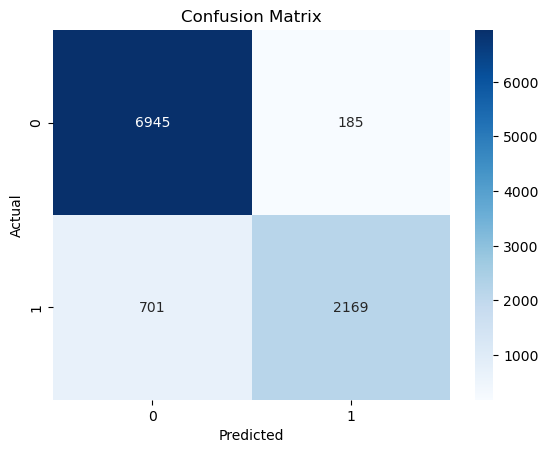

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

[TN  FP
 FN  TP]